# Smart Traffic Management System

## Exploratory Data Analysis





### Main goals
1. Understand the dataset and schema.
2. Determine row granularity.
3. Inspect SCATS sites, detectors, and intervals.
4. Investigate `V00`–`V95`.
5. Test the relationship between interval traffic and `QT_VOLUME_24HOUR`.
6. Check missing values and duplicates.
7. Identify potential target leakage.
8. Establish the information needed before ML/forecasting.

> EDA only: this notebook does not silently clean or delete observations.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Locate the processed dataset

The project processes daily `VSDATA_YYYYMMDD.csv` files. The pipeline logs show that these daily files contain roughly 113k–117k rows and 103 columns.

For interactive EDA we load a configurable sample first.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROCESSED_DIR = PROJECT_ROOT.parent / "data" / "processed"
else:
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Working directory :", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

csv_candidates = sorted(PROCESSED_DIR.glob("*.csv"))

for i, path in enumerate(csv_candidates, 1):
    print(f"{i:>2}. {path.name}")

# Change this explicitly if your final processed file has a known name.
if csv_candidates:
    DATA_PATH = csv_candidates[0]
else:
    DATA_PATH = Path("../data/processed/your_processed_file.csv")

print("\nDATA_PATH:", DATA_PATH)

Working directory : C:\Users\Aditya\Smart_traffic_management\notebooks
Processed directory: C:\Users\Aditya\Smart_traffic_management\data\processed
 1. traffic_2025.csv

DATA_PATH: C:\Users\Aditya\Smart_traffic_management\data\processed\traffic_2025.csv


In [3]:
SAMPLE_SIZE = 10_000

if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Set DATA_PATH to your processed CSV."
    )

df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE)

print(f"Loaded: {Path(DATA_PATH).name}")
print(f"Rows:   {len(df):,}")
print(f"Cols:   {df.shape[1]:,}")

Loaded: traffic_2025.csv
Rows:   10,000
Cols:   103


## 2. First look at the data

In [4]:
display(df.head())
display(df.sample(min(10, len(df)), random_state=42))
print("Shape:", df.shape)

,NB_SCATS_SITE,QT_INTERVAL_COUNT,NB_DETECTOR,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,NM_REGION,CT_RECORDS,QT_VOLUME_24HOUR,CT_ALARM_24HOUR
0,100,2025-04-01,1,2,1,1,2,4,1,4,0,1,1,1,0,1,0,0,1,0,0,1,0,3,4,4,3,7,12,16,11,5,9,15,12,26,13,20,20,21,14,9,11,10,7,14,16,14,14,11,17,17,22,17,15,14,19,11,12,29,20,26,11,15,13,14,18,17,15,19,16,21,12,15,14,19,17,15,10,11,7,13,8,12,5,3,12,4,10,8,18,11,10,12,9,4,7,3,3,WV1,96,992,0
1,100,2025-04-01,2,12,18,4,9,5,5,7,3,3,5,1,0,4,0,1,2,1,1,2,5,7,15,32,22,31,50,68,68,62,84,102,130,121,143,167,165,141,113,115,108,116,107,102,119,111,104,140,135,130,115,119,115,127,128,113,112,159,139,175,153,168,201,200,195,207,232,219,234,234,230,237,220,203,183,185,149,113,115,100,100,75,99,69,86,82,66,46,63,43,44,28,32,29,22,13,8,WV1,96,8881,0
2,100,2025-04-01,3,22,8,8,10,8,10,8,5,9,4,6,4,8,10,10,6,12,7,13,15,14,23,41,43,53,56,87,81,70,99,95,103,145,168,158,172,133,108,110,115,108,110,103,97,94,83,103,121,132,114,115,121,114,117,119,117,136,153,149,156,172,188,189,192,203,201,215,241,220,209,204,202,193,178,135,139,116,110,112,82,80,95,66,87,83,68,69,72,64,62,58,55,48,29,21,28,WV1,96,8905,0
3,100,2025-04-01,4,17,9,9,6,5,6,3,4,2,3,3,1,2,2,4,3,0,5,6,5,8,13,30,29,25,31,73,64,77,82,115,125,128,154,179,169,123,125,107,106,103,113,94,100,108,102,109,101,128,110,111,109,114,102,113,104,162,146,155,166,190,189,210,210,190,207,208,236,220,222,219,200,190,181,140,134,113,108,81,74,84,97,71,83,79,71,45,53,44,48,38,34,22,18,13,17,WV1,96,8547,0
4,100,2025-04-01,5,3,3,2,1,2,4,0,0,1,2,0,1,0,1,0,1,0,0,1,3,4,4,3,9,7,13,17,16,12,6,9,13,16,17,25,21,20,13,8,11,7,12,7,13,13,18,17,18,18,8,13,11,6,13,16,17,18,5,14,13,24,25,20,14,21,12,12,16,20,28,16,15,16,15,10,20,11,14,7,21,9,20,14,12,7,9,11,9,6,4,5,3,14,3,3,2,WV1,96,994,0


,NB_SCATS_SITE,QT_INTERVAL_COUNT,NB_DETECTOR,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,NM_REGION,CT_RECORDS,QT_VOLUME_24HOUR,CT_ALARM_24HOUR
6252,376,2025-04-01,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CRN,96,0,0
4684,307,2025-04-01,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,3,0,0,1,0,0,3,3,10,8,13,19,42,62,22,3,2,10,9,4,4,1,3,5,2,1,2,1,2,1,4,4,1,2,4,2,4,2,9,19,11,14,16,12,2,21,26,21,24,16,21,14,13,18,30,36,23,14,11,2,0,3,2,1,0,1,0,0,0,0,0,0,0,0,0,FRA,96,641,0
1731,175,2025-04-01,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,WV2,96,0,0
4742,309,2025-04-01,7,1,1,1,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,2,3,3,0,3,2,6,11,10,14,18,23,24,36,27,36,40,38,28,25,33,23,16,36,23,32,37,20,32,31,26,30,38,43,40,34,39,27,39,54,60,64,88,101,123,162,167,169,165,141,171,147,118,86,78,65,45,32,38,22,21,27,24,22,18,21,17,8,5,11,8,9,2,3,2,3,1,0,MEN,96,3253,0
4521,300,2025-04-01,18,1,1,1,0,0,0,2,0,0,1,2,0,1,2,1,3,3,9,10,15,16,16,19,21,21,18,19,20,21,24,31,38,36,44,68,64,36,23,24,19,18,22,16,15,18,13,14,13,17,15,14,17,17,9,24,18,14,24,23,23,37,44,43,18,21,19,14,19,21,18,21,19,24,16,19,16,12,12,13,9,11,9,13,4,5,6,4,5,3,4,1,0,1,2,1,0,WV2,96,1458,0
6340,383,2025-04-01,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,WV1,96,0,0
576,125,2025-04-01,1,5,2,0,2,1,0,0,0,1,0,0,2,3,1,1,1,2,3,5,11,16,10,37,36,50,75,86,71,75,102,103,103,96,114,128,110,96,69,58,58,47,65,65,54,66,60,57,66,68,64,47,63,72,53,77,75,74,59,61,80,77,88,70,90,84,90,77,82,105,117,98,86,91,68,51,58,50,51,32,42,41,36,31,35,30,23,21,20,22,13,12,9,12,3,5,5,BBN,96,4631,0
5202,331,2025-04-01,11,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,4,3,1,0,3,3,5,2,4,4,3,4,2,3,4,4,2,3,3,3,3,6,2,4,3,1,2,5,2,3,2,1,2,3,3,4,3,7,3,5,5,5,3,6,5,3,5,4,2,3,5,5,3,5,4,5,6,3,2,1,3,2,3,2,2,1,0,3,1,1,1,1,1,0,0,DON,96,228,0
6363,384,2025-04-01,12,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,2,1,2,2,1,1,1,6,6,3,6,5,2,5,3,4,3,3,3,1,0,2,1,7,2,2,1,1,0,2,0,1,3,5,1,1,1,3,1,3,2,1,1,2,0,2,2,0,2,1,2,2,4,2,4,1,3,2,3,0,0,0,0,1,1,0,1,0,1,1,0,0,0,0,0,WV2,96,140,0
439,118,2025-04-01,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CRN,96,0,0


Shape: (10000, 103)


In [5]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:>3}. {col}")

Columns:
  1. NB_SCATS_SITE
  2. QT_INTERVAL_COUNT
  3. NB_DETECTOR
  4. V00
  5. V01
  6. V02
  7. V03
  8. V04
  9. V05
 10. V06
 11. V07
 12. V08
 13. V09
 14. V10
 15. V11
 16. V12
 17. V13
 18. V14
 19. V15
 20. V16
 21. V17
 22. V18
 23. V19
 24. V20
 25. V21
 26. V22
 27. V23
 28. V24
 29. V25
 30. V26
 31. V27
 32. V28
 33. V29
 34. V30
 35. V31
 36. V32
 37. V33
 38. V34
 39. V35
 40. V36
 41. V37
 42. V38
 43. V39
 44. V40
 45. V41
 46. V42
 47. V43
 48. V44
 49. V45
 50. V46
 51. V47
 52. V48
 53. V49
 54. V50
 55. V51
 56. V52
 57. V53
 58. V54
 59. V55
 60. V56
 61. V57
 62. V58
 63. V59
 64. V60
 65. V61
 66. V62
 67. V63
 68. V64
 69. V65
 70. V66
 71. V67
 72. V68
 73. V69
 74. V70
 75. V71
 76. V72
 77. V73
 78. V74
 79. V75
 80. V76
 81. V77
 82. V78
 83. V79
 84. V80
 85. V81
 86. V82
 87. V83
 88. V84
 89. V85
 90. V86
 91. V87
 92. V88
 93. V89
 94. V90
 95. V91
 96. V92
 97. V93
 98. V94
 99. V95
100. NM_REGION
101. CT_RECORDS
102. QT_VOLUME_24HOUR
103. CT_ALARM_2

## 3. Data types and cardinality

In [6]:
dtype_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "n_unique": df.nunique(dropna=True)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

display(dtype_summary)

,dtype,missing_count,missing_pct,n_unique
QT_VOLUME_24HOUR,int64,0,0.000,3413
NB_SCATS_SITE,int64,0,0.000,396
V31,int64,0,0.000,294
V69,int64,0,0.000,293
V66,int64,0,0.000,292
...,...,...,...,...
NB_DETECTOR,int64,0,0.000,32
CT_ALARM_24HOUR,int64,0,0.000,19
NM_REGION,str,0,0.000,14
QT_INTERVAL_COUNT,str,0,0.000,1


In [7]:
print("Numeric columns :", df.select_dtypes(include=np.number).shape[1])
print("Object columns  :", df.select_dtypes(include="object").shape[1])
print("Datetime columns:", df.select_dtypes(include="datetime").shape[1])

Numeric columns : 101
Object columns  : 2
Datetime columns: 0


## 4. Missing values

In [8]:
missing_summary = (
    df.isna().sum()
      .to_frame("missing_count")
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(df) * 100
missing_summary = missing_summary.sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_pct


In [9]:
m = missing_summary[missing_summary["missing_count"] > 0].head(30)
if len(m):
    plt.figure(figsize=(12, 6))
    plt.barh(m.index[::-1], m["missing_pct"].values[::-1])
    plt.xlabel("Missing values (%)")
    plt.title("Top Columns by Missingness")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in the working sample.")

No missing values in the working sample.


## 5. Duplicate analysis

In [10]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate percentage:", f"{df.duplicated().mean()*100:.3f}%")

Exact duplicate rows: 0
Duplicate percentage: 0.000%


## 6. Core traffic columns

In [11]:
core_columns = [
    "NB_SCATS_SITE",
    "NB_DETECTOR",
    "QT_INTERVAL_COUNT",
    "NM_REGION",
    "QT_VOLUME_24HOUR"
]

available_core = [c for c in core_columns if c in df.columns]
missing_core = [c for c in core_columns if c not in df.columns]

print("Available:", available_core)
if missing_core:
    print("Not found:", missing_core)

display(df[available_core].head(20))

Available: ['NB_SCATS_SITE', 'NB_DETECTOR', 'QT_INTERVAL_COUNT', 'NM_REGION', 'QT_VOLUME_24HOUR']


,NB_SCATS_SITE,NB_DETECTOR,QT_INTERVAL_COUNT,NM_REGION,QT_VOLUME_24HOUR
0,100,1,2025-04-01,WV1,992
1,100,2,2025-04-01,WV1,8881
2,100,3,2025-04-01,WV1,8905
3,100,4,2025-04-01,WV1,8547
4,100,5,2025-04-01,WV1,994
5,100,6,2025-04-01,WV1,0
6,100,7,2025-04-01,WV1,0
7,100,8,2025-04-01,WV1,0
8,100,9,2025-04-01,WV1,0
9,100,10,2025-04-01,WV1,0


## 7. Identify `V00`–`V95` interval columns

In [12]:
traffic_columns = [
    c for c in df.columns
    if isinstance(c, str) and c.startswith("V")
]

print("Number of V* columns:", len(traffic_columns))
print(traffic_columns)

if traffic_columns:
    display(df[traffic_columns].head())

Number of V* columns: 96
['V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95']


,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,2,1,1,2,4,1,4,0,1,1,1,0,1,0,0,1,0,0,1,0,3,4,4,3,7,12,16,11,5,9,15,12,26,13,20,20,21,14,9,11,10,7,14,16,14,14,11,17,17,22,17,15,14,19,11,12,29,20,26,11,15,13,14,18,17,15,19,16,21,12,15,14,19,17,15,10,11,7,13,8,12,5,3,12,4,10,8,18,11,10,12,9,4,7,3,3
1,12,18,4,9,5,5,7,3,3,5,1,0,4,0,1,2,1,1,2,5,7,15,32,22,31,50,68,68,62,84,102,130,121,143,167,165,141,113,115,108,116,107,102,119,111,104,140,135,130,115,119,115,127,128,113,112,159,139,175,153,168,201,200,195,207,232,219,234,234,230,237,220,203,183,185,149,113,115,100,100,75,99,69,86,82,66,46,63,43,44,28,32,29,22,13,8
2,22,8,8,10,8,10,8,5,9,4,6,4,8,10,10,6,12,7,13,15,14,23,41,43,53,56,87,81,70,99,95,103,145,168,158,172,133,108,110,115,108,110,103,97,94,83,103,121,132,114,115,121,114,117,119,117,136,153,149,156,172,188,189,192,203,201,215,241,220,209,204,202,193,178,135,139,116,110,112,82,80,95,66,87,83,68,69,72,64,62,58,55,48,29,21,28
3,17,9,9,6,5,6,3,4,2,3,3,1,2,2,4,3,0,5,6,5,8,13,30,29,25,31,73,64,77,82,115,125,128,154,179,169,123,125,107,106,103,113,94,100,108,102,109,101,128,110,111,109,114,102,113,104,162,146,155,166,190,189,210,210,190,207,208,236,220,222,219,200,190,181,140,134,113,108,81,74,84,97,71,83,79,71,45,53,44,48,38,34,22,18,13,17
4,3,3,2,1,2,4,0,0,1,2,0,1,0,1,0,1,0,0,1,3,4,4,3,9,7,13,17,16,12,6,9,13,16,17,25,21,20,13,8,11,7,12,7,13,13,18,17,18,18,8,13,11,6,13,16,17,18,5,14,13,24,25,20,14,21,12,12,16,20,28,16,15,16,15,10,20,11,14,7,21,9,20,14,12,7,9,11,9,6,4,5,3,14,3,3,2


# 8. Row granularity — critical section

We do not assume what a row means. We test the relationship among:

`SCATS site + detector + interval + observation/date context`.

In [13]:
if "NB_SCATS_SITE" in df.columns:
    print("Unique SCATS sites:", df["NB_SCATS_SITE"].nunique())
    display(df["NB_SCATS_SITE"].value_counts().head(20))

if "NB_DETECTOR" in df.columns:
    print("Unique detectors:", df["NB_DETECTOR"].nunique())
    display(df["NB_DETECTOR"].value_counts().head(20))

Unique SCATS sites: 396


NB_SCATS_SITE
107    32
114    32
121    32
136    32
138    32
142    32
143    32
147    32
148    32
157    32
158    32
166    32
169    32
180    32
185    32
195    32
196    32
216    32
221    32
222    32
Name: count, dtype: int64

Unique detectors: 32


NB_DETECTOR
1     396
2     396
3     396
4     396
5     396
6     396
7     396
8     396
9     396
10    396
11    396
12    396
13    396
14    396
15    396
16    396
17    395
18    395
19    395
20    395
Name: count, dtype: int64

In [14]:
if {"NB_SCATS_SITE", "NB_DETECTOR"}.issubset(df.columns):
    site_detector = (
        df[["NB_SCATS_SITE", "NB_DETECTOR"]]
        .drop_duplicates()
        .sort_values(["NB_SCATS_SITE", "NB_DETECTOR"])
    )
    print("Unique site-detector combinations:", len(site_detector))
    display(site_detector.head(30))

Unique site-detector combinations: 10000


,NB_SCATS_SITE,NB_DETECTOR
0,100,1
1,100,2
2,100,3
3,100,4
4,100,5
5,100,6
6,100,7
7,100,8
8,100,9
9,100,10


In [15]:
if {"NB_SCATS_SITE", "NB_DETECTOR"}.issubset(df.columns):
    detectors_per_site = (
        df.groupby("NB_SCATS_SITE")["NB_DETECTOR"]
          .nunique()
          .sort_values(ascending=False)
    )
    display(detectors_per_site.describe())
    display(detectors_per_site.head(20))

count   396.000
mean     25.253
std       2.966
min      16.000
25%      24.000
50%      24.000
75%      24.000
max      32.000
Name: NB_DETECTOR, dtype: float64

NB_SCATS_SITE
157    32
166    32
138    32
222    32
223    32
169    32
107    32
142    32
143    32
307    32
510    32
263    32
248    32
147    32
148    32
280    32
195    32
196    32
519    32
265    32
Name: NB_DETECTOR, dtype: int64

## 9. Investigate `QT_INTERVAL_COUNT`

In [16]:
if "QT_INTERVAL_COUNT" in df.columns:
    display(df["QT_INTERVAL_COUNT"].describe())
    display(
        df["QT_INTERVAL_COUNT"]
        .value_counts(dropna=False)
        .sort_index()
        .head(150)
    )

count          10000
unique             1
top       2025-04-01
freq           10000
Name: QT_INTERVAL_COUNT, dtype: object

QT_INTERVAL_COUNT
2025-04-01    10000
Name: count, dtype: int64

## 10. Candidate key: site + detector + interval

In [17]:
candidate_key = [
    c for c in ["NB_SCATS_SITE", "NB_DETECTOR", "QT_INTERVAL_COUNT"]
    if c in df.columns
]

print("Candidate key:", candidate_key)

if candidate_key:
    key_counts = (
        df.groupby(candidate_key)
          .size()
          .sort_values(ascending=False)
    )
    display(key_counts.describe())
    display(key_counts.head(20))

    duplicate_key_mask = df.duplicated(subset=candidate_key, keep=False)
    print("Rows involved in repeated candidate keys:", duplicate_key_mask.sum())

Candidate key: ['NB_SCATS_SITE', 'NB_DETECTOR', 'QT_INTERVAL_COUNT']


count   10,000.000
mean         1.000
std          0.000
min          1.000
25%          1.000
50%          1.000
75%          1.000
max          1.000
dtype: float64

NB_SCATS_SITE  NB_DETECTOR  QT_INTERVAL_COUNT
100            1            2025-04-01           1
               2            2025-04-01           1
               3            2025-04-01           1
               4            2025-04-01           1
               5            2025-04-01           1
               6            2025-04-01           1
               7            2025-04-01           1
               8            2025-04-01           1
               9            2025-04-01           1
               10           2025-04-01           1
               11           2025-04-01           1
               12           2025-04-01           1
               13           2025-04-01           1
               14           2025-04-01           1
               15           2025-04-01           1
               16           2025-04-01           1
               17           2025-04-01           1
               18           2025-04-01           1
               19           2025-04-

Rows involved in repeated candidate keys: 0


# 11. Leakage investigation: do `V00`–`V95` reconstruct `QT_VOLUME_24HOUR`?

This is one of the most important tests.

If the interval columns sum to the daily volume, then using same-day interval measurements to predict same-day total volume can produce an unrealistic ML problem.

In [18]:
if traffic_columns and "QT_VOLUME_24HOUR" in df.columns:
    interval_sum = df[traffic_columns].sum(axis=1, skipna=False)

    comparison = pd.DataFrame({
        "interval_sum": interval_sum,
        "daily_volume": df["QT_VOLUME_24HOUR"]
    })
    comparison["difference"] = (
        comparison["interval_sum"] - comparison["daily_volume"]
    )

    display(comparison.head(20))
    print("Rows where sums differ:",
          (comparison["difference"] != 0).sum())
    print("Rows with missing comparison:",
          comparison.isna().any(axis=1).sum())
    print("Maximum absolute difference:",
          comparison["difference"].abs().max())

,interval_sum,daily_volume,difference
0,992,992,0
1,8881,8881,0
2,8905,8905,0
3,8547,8547,0
4,994,994,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,0,0


Rows where sums differ: 202
Rows with missing comparison: 0
Maximum absolute difference: 9955


In [19]:
if "comparison" in globals():
    display(comparison["difference"].describe())
    display(comparison[["interval_sum", "daily_volume"]].corr())

count   10,000.000
mean        20.475
std        306.316
min        -96.000
25%          0.000
50%          0.000
75%          0.000
max      9,955.000
Name: difference, dtype: float64

,interval_sum,daily_volume
interval_sum,1.000,0.994
daily_volume,0.994,1.000


## 12. Traffic interval quality checks

In [20]:
if traffic_columns:
    interval_summary = pd.DataFrame({
        "missing_count": df[traffic_columns].isna().sum(),
        "missing_pct": df[traffic_columns].isna().mean() * 100,
        "zero_count": (df[traffic_columns] == 0).sum(),
        "negative_count": (df[traffic_columns] < 0).sum(),
        "mean": df[traffic_columns].mean(),
        "median": df[traffic_columns].median(),
        "max": df[traffic_columns].max()
    })
    display(interval_summary)

,missing_count,missing_pct,zero_count,negative_count,mean,median,max
V00,0,0.000,6479,112,3.119,0.000,759
V01,0,0.000,6664,112,2.729,0.000,759
V02,0,0.000,6794,112,2.458,0.000,759
V03,0,0.000,6903,112,2.202,0.000,759
V04,0,0.000,7006,112,1.958,0.000,759
...,...,...,...,...,...,...,...
V91,0,0.000,6012,111,5.702,0.000,558
V92,0,0.000,6075,111,5.124,0.000,594
V93,0,0.000,6218,111,4.316,0.000,506
V94,0,0.000,6328,111,3.617,0.000,666


## 13. Numerical summary

In [21]:
numeric_df = df.select_dtypes(include=np.number)
numeric_summary = numeric_df.describe().T
numeric_summary["missing_count"] = numeric_df.isna().sum()
numeric_summary["n_unique"] = numeric_df.nunique(dropna=True)
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing_count,n_unique
NB_SCATS_SITE,"10,000.000",322.427,129.808,100.000,211.000,319.500,437.000,548.000,0,396
NB_DETECTOR,"10,000.000",13.098,7.542,0.000,7.000,13.000,19.000,31.000,0,32
V00,"10,000.000",3.119,19.614,-1.000,0.000,0.000,2.000,759.000,0,80
V01,"10,000.000",2.729,19.673,-1.000,0.000,0.000,2.000,759.000,0,74
V02,"10,000.000",2.458,20.417,-1.000,0.000,0.000,1.000,759.000,0,64
...,...,...,...,...,...,...,...,...,...,...
V94,"10,000.000",3.617,12.644,-1.000,0.000,0.000,3.000,666.000,0,83
V95,"10,000.000",2.963,11.618,-1.000,0.000,0.000,2.000,659.000,0,71
CT_RECORDS,"10,000.000",96.000,0.000,96.000,96.000,96.000,96.000,96.000,0,1
QT_VOLUME_24HOUR,"10,000.000","1,615.496","2,834.122",-1.000,0.000,0.000,"2,183.250","41,669.000",0,3413


In [22]:
constant_columns = [
    c for c in df.columns
    if df[c].nunique(dropna=False) <= 1
]
print("Constant/single-value columns:", constant_columns)

Constant/single-value columns: ['QT_INTERVAL_COUNT', 'CT_RECORDS']


## 14. Cardinality of variables

In [23]:
cardinality = pd.DataFrame({
    "n_unique": df.nunique(dropna=True),
    "unique_ratio": df.nunique(dropna=True) / len(df),
    "dtype": df.dtypes.astype(str)
}).sort_values("n_unique", ascending=False)

display(cardinality.head(40))

,n_unique,unique_ratio,dtype
QT_VOLUME_24HOUR,3413,0.341,int64
NB_SCATS_SITE,396,0.040,int64
V31,294,0.029,int64
V69,293,0.029,int64
V66,292,0.029,int64
V67,292,0.029,int64
V68,292,0.029,int64
V64,291,0.029,int64
V33,289,0.029,int64
V29,287,0.029,int64


## 15. Daily traffic distribution

count   10,000.000
mean     1,615.496
std      2,834.122
min         -1.000
25%          0.000
50%          0.000
75%      2,183.250
max     41,669.000
Name: QT_VOLUME_24HOUR, dtype: float64

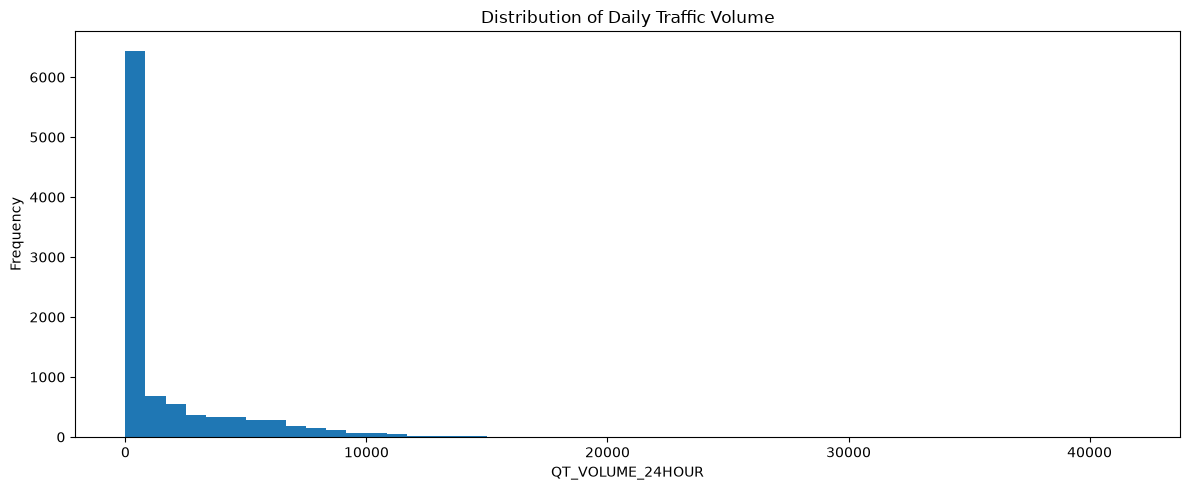

In [24]:
if "QT_VOLUME_24HOUR" in df.columns:
    target = df["QT_VOLUME_24HOUR"].dropna()
    display(target.describe())

    plt.figure(figsize=(12, 5))
    plt.hist(target, bins=50)
    plt.xlabel("QT_VOLUME_24HOUR")
    plt.ylabel("Frequency")
    plt.title("Distribution of Daily Traffic Volume")
    plt.tight_layout()
    plt.show()

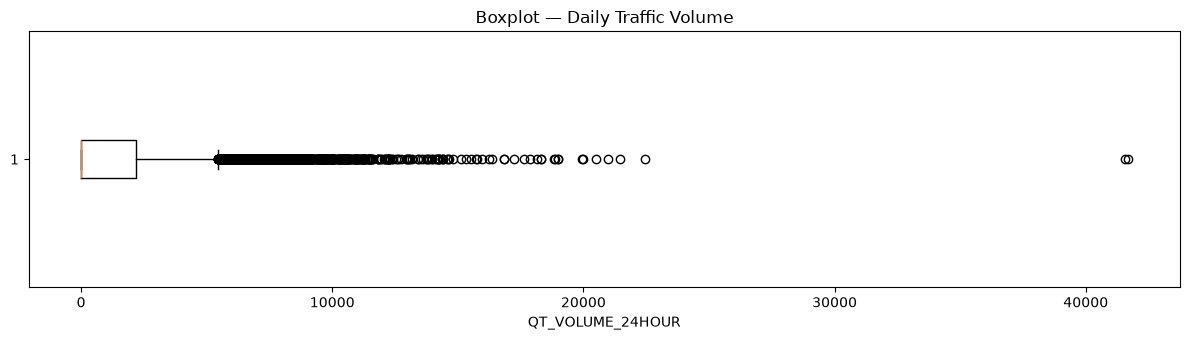

In [25]:
if "QT_VOLUME_24HOUR" in df.columns:
    plt.figure(figsize=(12, 3.5))
    plt.boxplot(df["QT_VOLUME_24HOUR"].dropna(), vert=False)
    plt.xlabel("QT_VOLUME_24HOUR")
    plt.title("Boxplot — Daily Traffic Volume")
    plt.tight_layout()
    plt.show()

## 16. Date/time-like columns

In [26]:
time_keywords = ("date", "time", "day", "month", "year", "hour", "timestamp")

time_like_columns = [
    c for c in df.columns
    if any(k in str(c).lower() for k in time_keywords)
]

print("Potential date/time columns:")
print(time_like_columns)

if time_like_columns:
    display(df[time_like_columns].head(20))

Potential date/time columns:
['QT_VOLUME_24HOUR', 'CT_ALARM_24HOUR']


,QT_VOLUME_24HOUR,CT_ALARM_24HOUR
0,992,0
1,8881,0
2,8905,0
3,8547,0
4,994,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


## 17. Average traffic profile across V00–V95

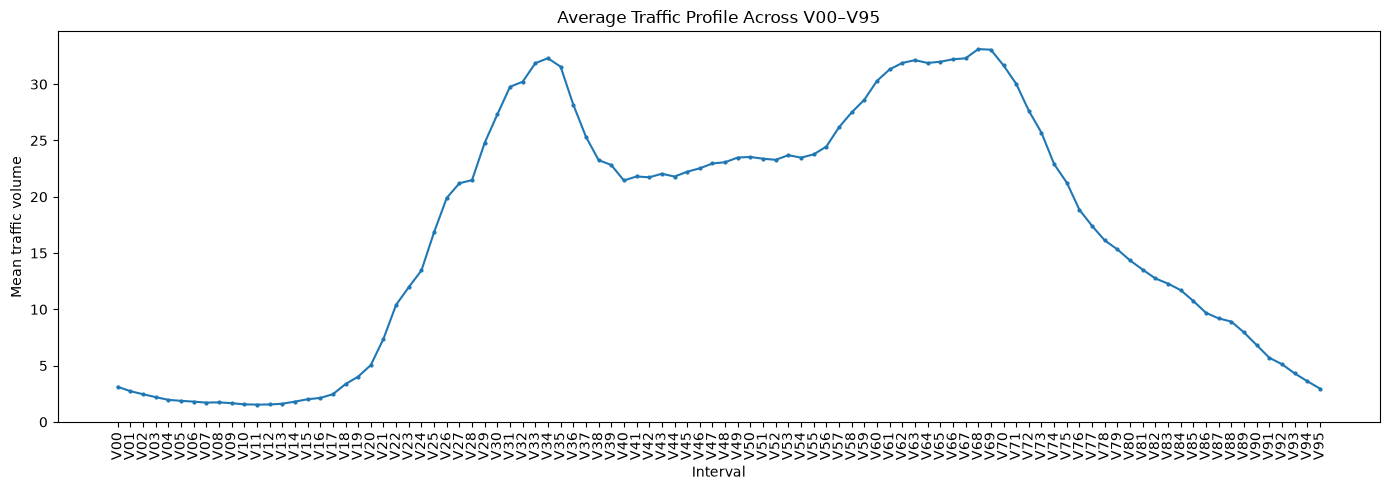

In [27]:
if traffic_columns:
    interval_means = df[traffic_columns].mean()

    plt.figure(figsize=(14, 5))
    plt.plot(
        range(len(interval_means)),
        interval_means.values,
        marker="o",
        markersize=2
    )
    plt.xlabel("Interval")
    plt.ylabel("Mean traffic volume")
    plt.title("Average Traffic Profile Across V00–V95")
    plt.xticks(
        range(len(interval_means)),
        interval_means.index,
        rotation=90
    )
    plt.tight_layout()
    plt.show()

## 18. Zero-volume profile

In [28]:
if traffic_columns:
    zero_pct = (
        (df[traffic_columns] == 0).mean() * 100
    ).sort_values(ascending=False)
    display(zero_pct.to_frame("zero_percentage").head(30))

,zero_percentage
V11,75.440
V12,74.430
V10,74.340
V09,74.310
V08,73.930
V13,73.840
V14,73.230
V07,72.220
V15,72.120
V06,71.450


# 19. Correlation analysis

Correlation is diagnostic, not final feature selection.

,NB_SCATS_SITE,NB_DETECTOR,QT_VOLUME_24HOUR,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
NB_SCATS_SITE,1.000,-0.006,-0.023,-0.035,-0.033,-0.039,-0.038,-0.039,-0.041,-0.040,-0.039,-0.043,-0.043,-0.040,-0.043,-0.044,-0.046,-0.045,-0.044,-0.041,-0.034,-0.031,-0.034
NB_DETECTOR,-0.006,1.000,-0.458,-0.107,-0.087,-0.074,-0.069,-0.060,-0.049,-0.046,-0.036,-0.038,-0.038,-0.037,-0.037,-0.039,-0.043,-0.045,-0.051,-0.059,-0.076,-0.121,-0.166
QT_VOLUME_24HOUR,-0.023,-0.458,1.000,0.430,0.404,0.373,0.365,0.314,0.309,0.304,0.306,0.297,0.286,0.281,0.276,0.278,0.273,0.287,0.303,0.321,0.355,0.439,0.498
V00,-0.035,-0.107,0.430,1.000,0.942,0.885,0.906,0.811,0.806,0.797,0.813,0.845,0.866,0.874,0.866,0.889,0.894,0.907,0.904,0.888,0.904,0.856,0.756
V01,-0.033,-0.087,0.404,0.942,1.000,0.937,0.918,0.790,0.810,0.848,0.859,0.869,0.905,0.905,0.884,0.934,0.924,0.915,0.902,0.888,0.933,0.848,0.767
V02,-0.039,-0.074,0.373,0.885,0.937,1.000,0.940,0.799,0.826,0.818,0.840,0.855,0.910,0.954,0.920,0.930,0.926,0.904,0.892,0.835,0.893,0.814,0.745
V03,-0.038,-0.069,0.365,0.906,0.918,0.940,1.000,0.915,0.901,0.887,0.901,0.908,0.938,0.956,0.924,0.937,0.932,0.935,0.927,0.889,0.895,0.825,0.723
V04,-0.039,-0.060,0.314,0.811,0.790,0.799,0.915,1.000,0.978,0.947,0.931,0.938,0.912,0.880,0.880,0.869,0.869,0.902,0.905,0.882,0.805,0.741,0.614
V05,-0.041,-0.049,0.309,0.806,0.810,0.826,0.901,0.978,1.000,0.966,0.959,0.969,0.938,0.891,0.904,0.887,0.886,0.916,0.927,0.899,0.815,0.760,0.644
V06,-0.040,-0.046,0.304,0.797,0.848,0.818,0.887,0.947,0.966,1.000,0.978,0.969,0.933,0.877,0.874,0.895,0.883,0.914,0.917,0.911,0.840,0.764,0.661


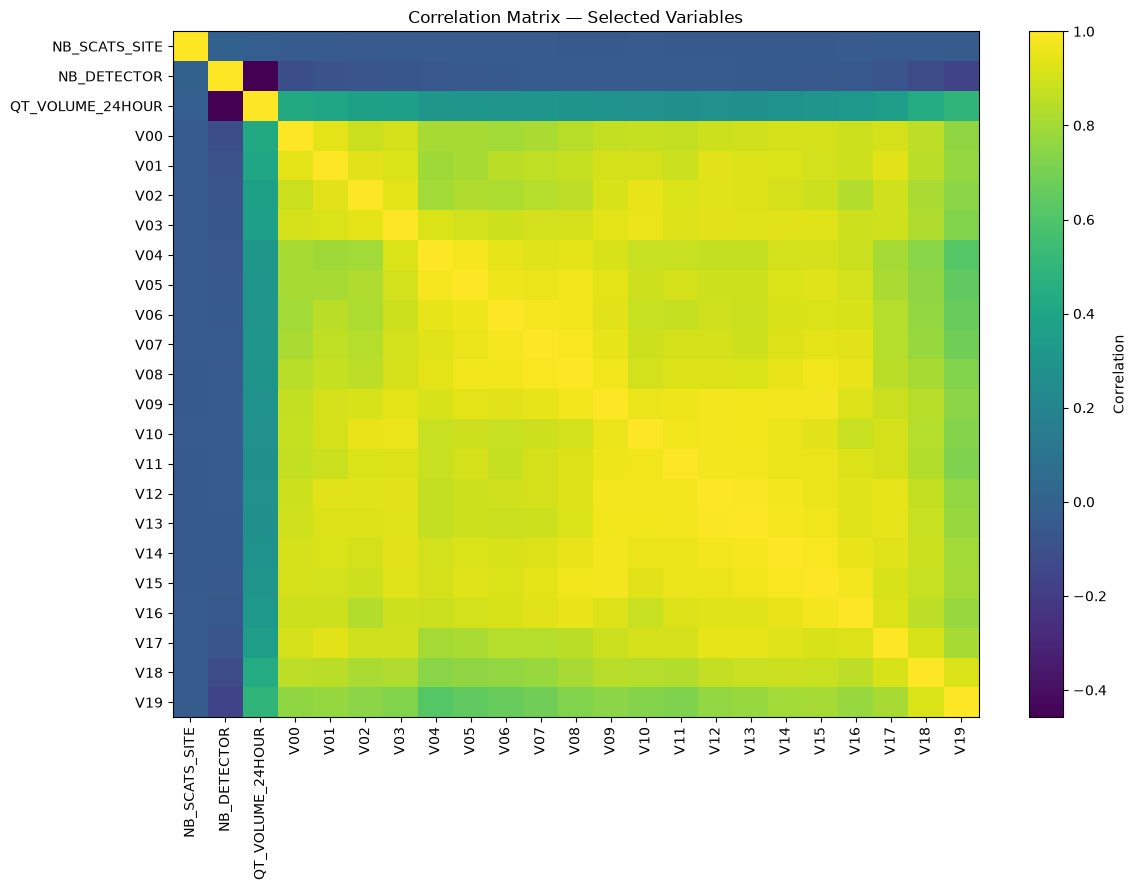

In [29]:
corr_cols = [
    c for c in [
        "NB_SCATS_SITE",
        "NB_DETECTOR",
        "QT_INTERVAL_COUNT",
        "QT_VOLUME_24HOUR"
    ] if c in df.columns
] + traffic_columns[:20]

corr_cols = list(dict.fromkeys(corr_cols))

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(12, 9))
    plt.imshow(corr, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Matrix — Selected Variables")
    plt.tight_layout()
    plt.show()

# 20. Preliminary ML problem definition

Do not start model training yet.

Potential formulations:

### A. Daily volume prediction
Historical/site/time information → `QT_VOLUME_24HOUR`

### B. Next-interval prediction
Past intervals → next traffic interval

### C. Future site/detector traffic
Site + detector + historical traffic + temporal features → future traffic

For a Smart Traffic Management System, a future/next-interval prediction problem is generally more operationally meaningful than reconstructing a same-day total from measurements already observed that day.

The final choice must be based on the confirmed temporal structure.

# 21. Leakage checklist

Before ML:

- [ ] Target is not an input feature.
- [ ] Same-time/future measurements are not used to predict the past.
- [ ] Same-day variables mathematically derived from the target are handled carefully.
- [ ] Lag features use only earlier observations.
- [ ] Rolling statistics do not include future values.
- [ ] Train/validation/test split respects time.
- [ ] Aggregations do not leak information across the split.

In [30]:
print("=" * 70)
print("SMART TRAFFIC MANAGEMENT SYSTEM — EDA SNAPSHOT")
print("=" * 70)
print(f"Dataset:              {Path(DATA_PATH).name}")
print(f"Rows analyzed:        {len(df):,}")
print(f"Columns:              {df.shape[1]:,}")
print(f"Missing cells:        {int(df.isna().sum().sum()):,}")
print(f"Exact duplicate rows: {int(df.duplicated().sum()):,}")
print(f"V* interval columns:  {len(traffic_columns):,}")

if "NB_SCATS_SITE" in df.columns:
    print(f"Unique SCATS sites:   {df['NB_SCATS_SITE'].nunique():,}")

if "NB_DETECTOR" in df.columns:
    print(f"Unique detectors:     {df['NB_DETECTOR'].nunique():,}")

if "QT_INTERVAL_COUNT" in df.columns:
    print(f"Unique interval vals: {df['QT_INTERVAL_COUNT'].nunique():,}")

if "QT_VOLUME_24HOUR" in df.columns:
    print(f"Daily volume missing: {int(df['QT_VOLUME_24HOUR'].isna().sum()):,}")

print("=" * 70)

SMART TRAFFIC MANAGEMENT SYSTEM — EDA SNAPSHOT
Dataset:              traffic_2025.csv
Rows analyzed:        10,000
Columns:              103
Missing cells:        0
Exact duplicate rows: 0
V* interval columns:  96
Unique SCATS sites:   396
Unique detectors:     32
Unique interval vals: 1
Daily volume missing: 0


# 22. EDA Findings — fill after execution

### Dataset
- Rows:
- Columns:
- Important identifiers:
- Traffic interval columns:

### Row granularity
- One row represents:
- SCATS site relationship:
- Detector relationship:
- Interval relationship:
- Date/time field:

### Data quality
- Missing values:
- Exact duplicates:
- Duplicate candidate keys:
- Negative traffic values:
- Zero traffic:

### Traffic structure
- Meaning of `QT_INTERVAL_COUNT`:
- Relationship between `V00`–`V95` and `QT_VOLUME_24HOUR`:

### ML implications
- Prediction target:
- Prediction horizon:
- Features available at prediction time:
- Leakage variables:
- Validation strategy:

> Do not fill these from assumptions. Fill them from the executed outputs.